In [1]:
# 1. Environment & Path Setup
import os
import sys

# Add the project root directory to sys.path so 'pipeline' is importable
sys.path.append(os.path.abspath('../..'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


In [2]:
import duckdb

DB_PATH = '/home/kishor/Projects/ShotDist/shotdistributionpredictor/data/events.db'
con = duckdb.connect(DB_PATH, read_only = True)
pm_df = con.execute("SELECT * FROM opspatial WHERE total_reception_events >= 15 AND total_release_events >= 15 AND position != 'Goalkeeper'").df()
con.close()

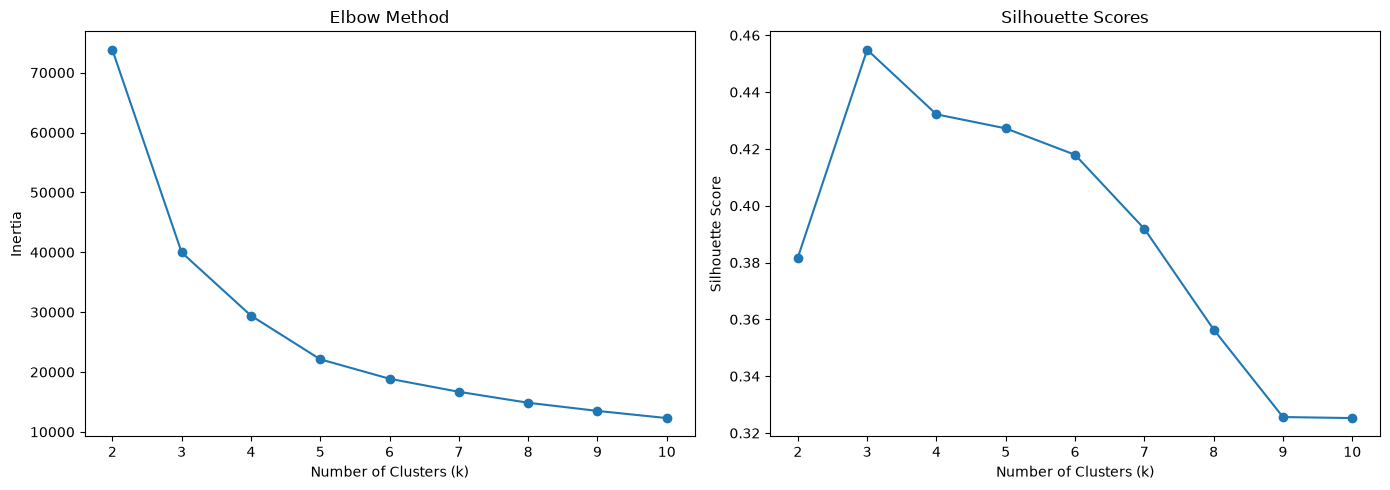

In [3]:
pm_df["avg_reception_simpnorm_y"] = np.where(
    pm_df["average_reception_y"] <= 40,
    pm_df["average_reception_y"],
    80 - pm_df["average_reception_y"],
)

pm_df["avg_release_simpnorm_y"] = np.where(
    pm_df["average_release_y"] <= 40,
    pm_df["average_release_y"],
    80 - pm_df["average_release_y"],
)

pm_df["avg_reception_simpnorm_y_abs"] = pm_df["avg_reception_simpnorm_y"].abs()
pm_df["avg_release_simpnorm_y_abs"] = pm_df["avg_release_simpnorm_y"].abs()

feature_cols = [
    "average_reception_x",
    "avg_reception_simpnorm_y_abs",
    "average_release_x",
    "avg_release_simpnorm_y_abs",
]
pm_X = pm_df[feature_cols].dropna()
pm_X_scaled = StandardScaler().fit_transform(pm_X)

pm_k_range = range(2, 11)
pm_inertia = []
pm_silhouette_scores = []

for n_clusters in pm_k_range:
    model = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    labels = model.fit_predict(pm_X_scaled)

    pm_inertia.append(model.inertia_)
    pm_silhouette_scores.append(
        silhouette_score(
            pm_X_scaled,
            labels,
            sample_size=min(5000, len(pm_X_scaled)),
            random_state=42,
        )
    )

fig_pm, (ax1_pm, ax2_pm) = plt.subplots(1, 2, figsize=(14, 5))

ax1_pm.plot(list(pm_k_range), pm_inertia, marker="o")
ax1_pm.set(title="Elbow Method", xlabel="Number of Clusters (k)", ylabel="Inertia")

ax2_pm.plot(list(pm_k_range), pm_silhouette_scores, marker="o")
ax2_pm.set(title="Silhouette Scores", xlabel="Number of Clusters (k)", ylabel="Silhouette Score")

plt.tight_layout()
plt.show()

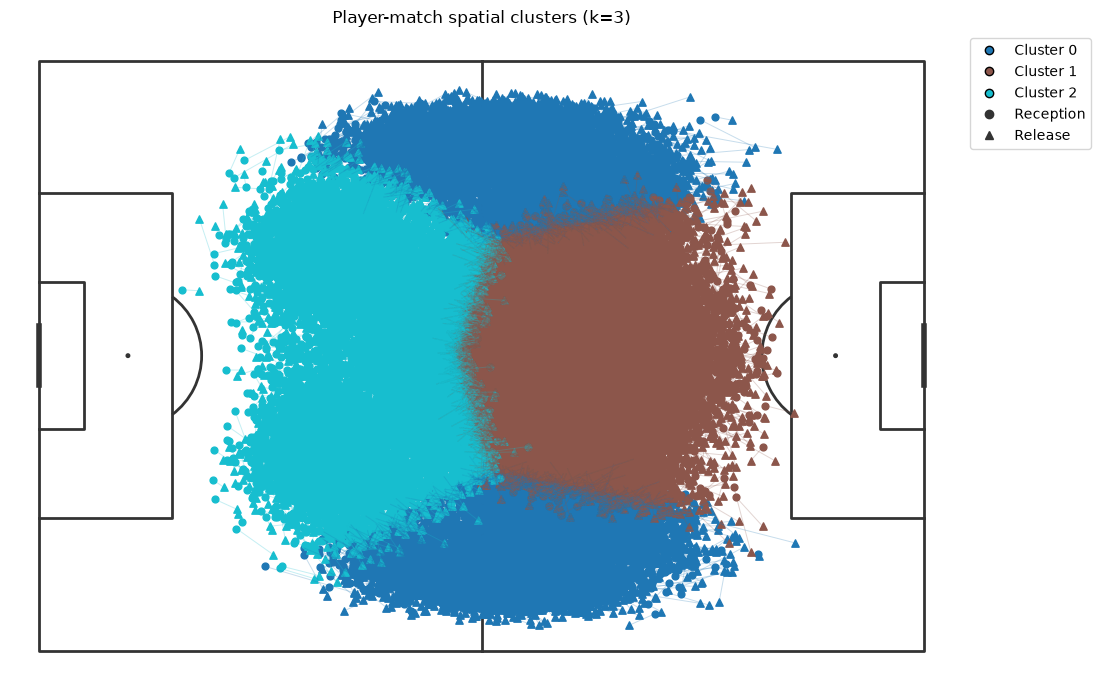

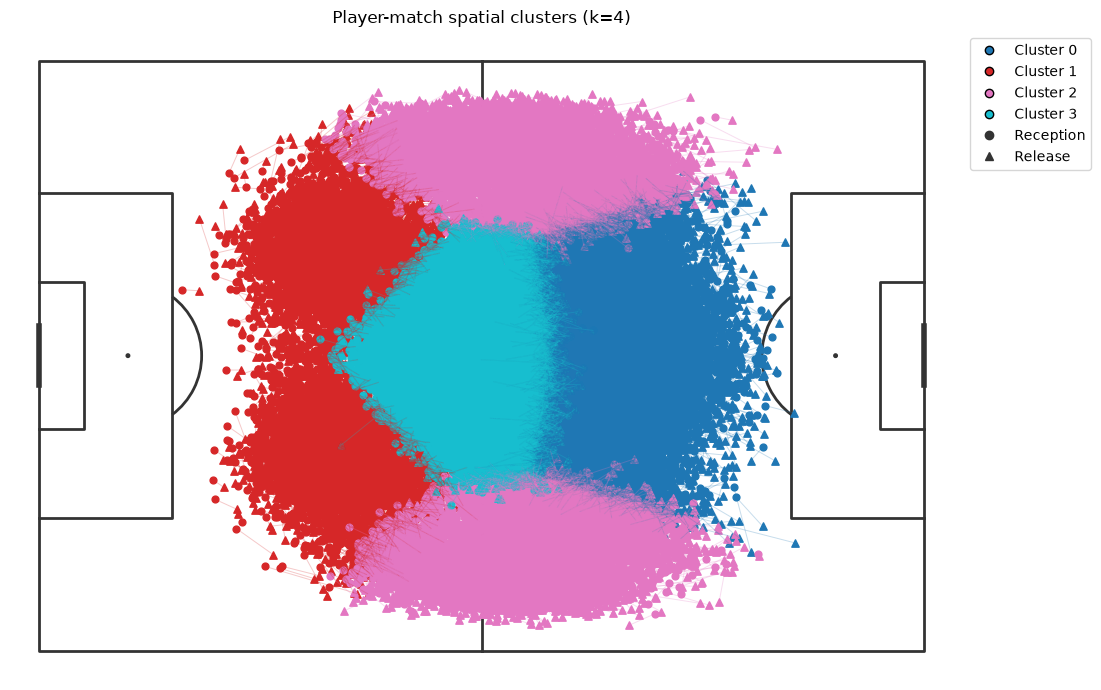

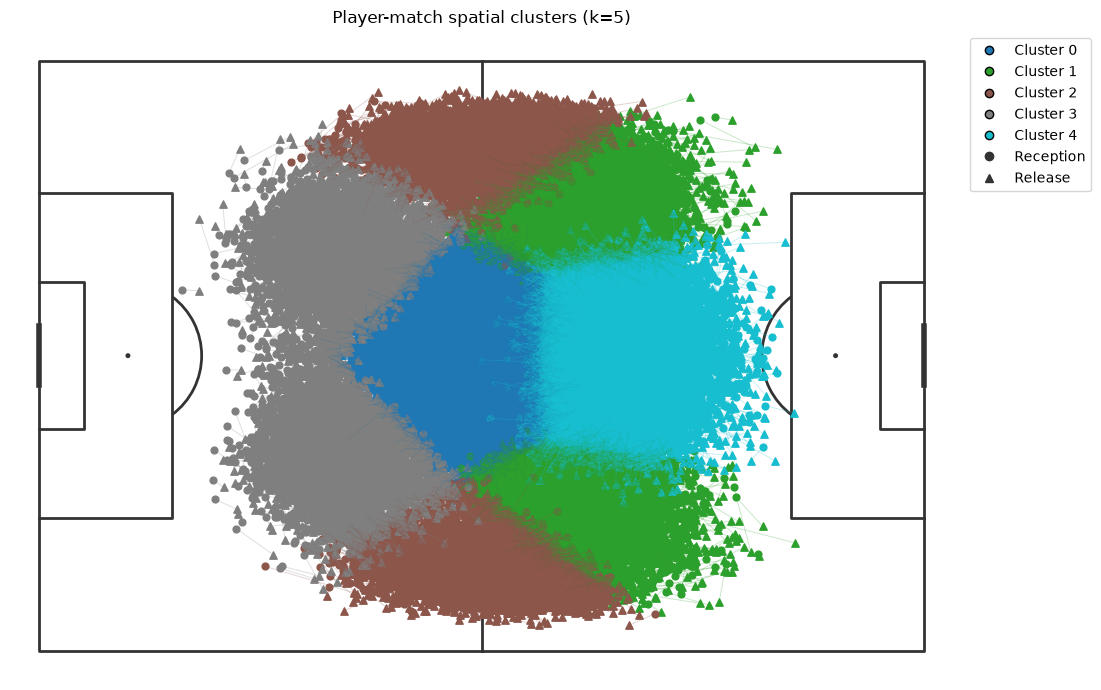

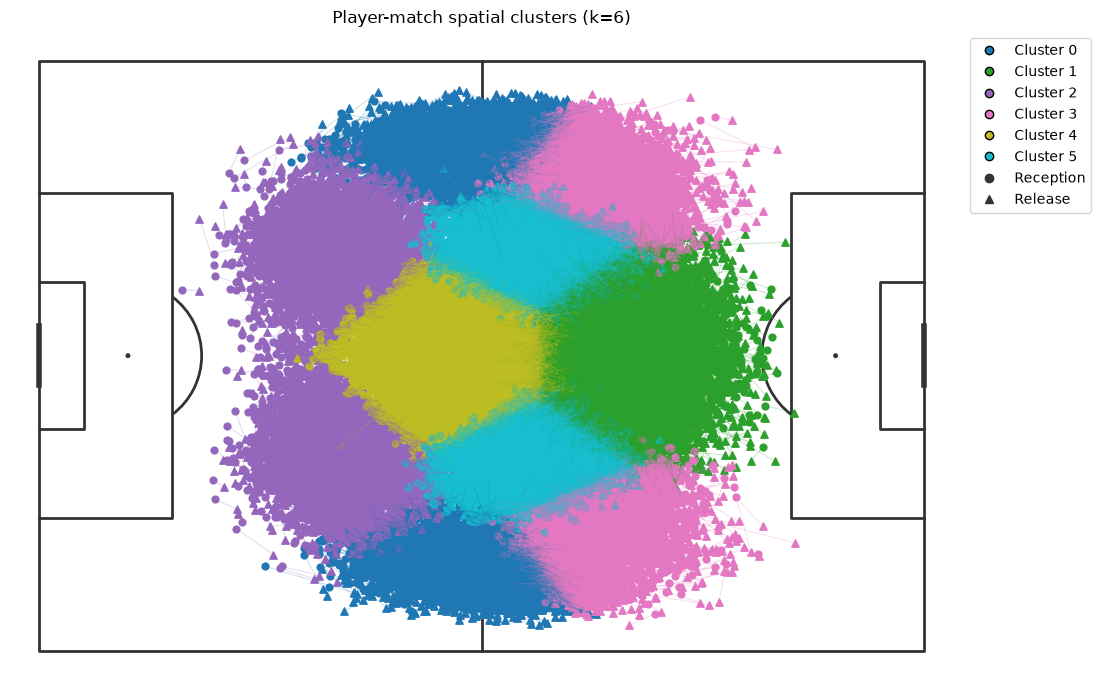

,k,cluster,player_match_pair_rows
0,3,0,9663
1,3,1,12140
2,3,2,9072
3,4,0,8201
4,4,1,5850
5,4,2,9388
6,4,3,7436
7,5,0,7076
8,5,1,5212
9,5,2,6391


In [5]:
from mplsoccer import Pitch
from IPython.display import display
from matplotlib.lines import Line2D

pm_X = pm_df[feature_cols].dropna()
pm_X_scaled = StandardScaler().fit_transform(pm_X)
cluster_data = pm_df.loc[pm_X.index].copy()
cluster_counts = []

for n_clusters in [3, 4, 5, 6]:
    model = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    cluster_data[f"cluster_k{n_clusters}"] = model.fit_predict(pm_X_scaled)
    pm_df[f"cluster_k{n_clusters}"] = cluster_data[f"cluster_k{n_clusters}"]

    counts = (
        cluster_data.groupby(f"cluster_k{n_clusters}")
        .size()
        .rename("player_match_pair_rows")
        .reset_index()
        .rename(columns={f"cluster_k{n_clusters}": "cluster"})
    )
    counts.insert(0, "k", n_clusters)
    cluster_counts.append(counts)

    pitch = Pitch(pitch_type="statsbomb", pitch_color="white", line_color="#333333")
    fig, ax = pitch.draw(figsize=(11, 7))
    color_map = plt.get_cmap("tab10", n_clusters)
    cluster_col = f"cluster_k{n_clusters}"

    for cluster in range(n_clusters):
        cluster_rows = cluster_data[cluster_data[cluster_col] == cluster]
        color = color_map(cluster)
        pitch.lines(
            cluster_rows["average_reception_x"],
            cluster_rows["average_reception_y"],
            cluster_rows["average_release_x"],
            cluster_rows["average_release_y"],
            color=color,
            alpha=0.25,
            lw=0.7,
            ax=ax,
        )
        pitch.scatter(
            cluster_rows["average_reception_x"],
            cluster_rows["average_reception_y"],
            color=color,
            marker="o",
            s=24,
            ax=ax,
        )
        pitch.scatter(
            cluster_rows["average_release_x"],
            cluster_rows["average_release_y"],
            color=color,
            marker="^",
            s=28,
            ax=ax,
        )

    cluster_handles = [
        Line2D([0], [0], marker="o", color="none", markerfacecolor=color_map(cluster), label=f"Cluster {cluster}")
        for cluster in range(n_clusters)
    ]
    cluster_handles.extend(
        [
            Line2D([0], [0], marker="o", color="#333333", linestyle="none", label="Reception"),
            Line2D([0], [0], marker="^", color="#333333", linestyle="none", label="Release"),
        ]
    )
    ax.legend(handles=cluster_handles, loc="upper left", bbox_to_anchor=(1.01, 1))
    ax.set_title(f"Player-match spatial clusters (k={n_clusters})")
    plt.tight_layout()
    plt.show()

cluster_count_df = pd.concat(cluster_counts, ignore_index=True)
display(cluster_count_df)

In [ ]:
cluster_k3_0_df = pm_df[pm_df["cluster_k3"] == 0].copy()
cluster_k3_1_df = pm_df[pm_df["cluster_k3"] == 1].copy()
cluster_k3_2_df = pm_df[pm_df["cluster_k3"] == 2].copy()

cluster_k4_0_df = pm_df[pm_df["cluster_k4"] == 0].copy()
cluster_k4_1_df = pm_df[pm_df["cluster_k4"] == 1].copy()
cluster_k4_2_df = pm_df[pm_df["cluster_k4"] == 2].copy()
cluster_k4_3_df = pm_df[pm_df["cluster_k4"] == 3].copy()

cluster_k5_0_df = pm_df[pm_df["cluster_k5"] == 0].copy()
cluster_k5_1_df = pm_df[pm_df["cluster_k5"] == 1].copy()
cluster_k5_2_df = pm_df[pm_df["cluster_k5"] == 2].copy()
cluster_k5_3_df = pm_df[pm_df["cluster_k5"] == 3].copy()
cluster_k5_4_df = pm_df[pm_df["cluster_k5"] == 4].copy()

cluster_k6_0_df = pm_df[pm_df["cluster_k6"] == 0].copy()
cluster_k6_1_df = pm_df[pm_df["cluster_k6"] == 1].copy()
cluster_k6_2_df = pm_df[pm_df["cluster_k6"] == 2].copy()
cluster_k6_3_df = pm_df[pm_df["cluster_k6"] == 3].copy()
cluster_k6_4_df = pm_df[pm_df["cluster_k6"] == 4].copy()
cluster_k6_5_df = pm_df[pm_df["cluster_k6"] == 5].copy()

In [7]:
positions_k3_0 = cluster_k3_0_df["position"].unique()
positions_k3_1 = cluster_k3_1_df["position"].unique()
positions_k3_2 = cluster_k3_2_df["position"].unique()

positions_k4_0 = cluster_k4_0_df["position"].unique()
positions_k4_1 = cluster_k4_1_df["position"].unique()
positions_k4_2 = cluster_k4_2_df["position"].unique()
positions_k4_3 = cluster_k4_3_df["position"].unique()

positions_k5_0 = cluster_k5_0_df["position"].unique()
positions_k5_1 = cluster_k5_1_df["position"].unique()
positions_k5_2 = cluster_k5_2_df["position"].unique()
positions_k5_3 = cluster_k5_3_df["position"].unique()
positions_k5_4 = cluster_k5_4_df["position"].unique()

positions_k6_0 = cluster_k6_0_df["position"].unique()
positions_k6_1 = cluster_k6_1_df["position"].unique()
positions_k6_2 = cluster_k6_2_df["position"].unique()
positions_k6_3 = cluster_k6_3_df["position"].unique()
positions_k6_4 = cluster_k6_4_df["position"].unique()
positions_k6_5 = cluster_k6_5_df["position"].unique()

In [13]:
position_counts_k3_0 = cluster_k3_0_df["position"].value_counts()
position_counts_k3_1 = cluster_k3_1_df["position"].value_counts()
position_counts_k3_2 = cluster_k3_2_df["position"].value_counts()

position_counts_k4_0 = cluster_k4_0_df["position"].value_counts()
position_counts_k4_1 = cluster_k4_1_df["position"].value_counts()
position_counts_k4_2 = cluster_k4_2_df["position"].value_counts()
position_counts_k4_3 = cluster_k4_3_df["position"].value_counts()

position_counts_k5_0 = cluster_k5_0_df["position"].value_counts()
position_counts_k5_1 = cluster_k5_1_df["position"].value_counts()
position_counts_k5_2 = cluster_k5_2_df["position"].value_counts()
position_counts_k5_3 = cluster_k5_3_df["position"].value_counts()
position_counts_k5_4 = cluster_k5_4_df["position"].value_counts()

position_counts_k6_0 = cluster_k6_0_df["position"].value_counts()
position_counts_k6_1 = cluster_k6_1_df["position"].value_counts()
position_counts_k6_2 = cluster_k6_2_df["position"].value_counts()
position_counts_k6_3 = cluster_k6_3_df["position"].value_counts()
position_counts_k6_4 = cluster_k6_4_df["position"].value_counts()
position_counts_k6_5 = cluster_k6_5_df["position"].value_counts()

In [14]:
position_counts_df = pd.concat(
    {
        "cluster_k3_0": position_counts_k3_0,
        "cluster_k3_1": position_counts_k3_1,
        "cluster_k3_2": position_counts_k3_2,
        "cluster_k4_0": position_counts_k4_0,
        "cluster_k4_1": position_counts_k4_1,
        "cluster_k4_2": position_counts_k4_2,
        "cluster_k4_3": position_counts_k4_3,
        "cluster_k5_0": position_counts_k5_0,
        "cluster_k5_1": position_counts_k5_1,
        "cluster_k5_2": position_counts_k5_2,
        "cluster_k5_3": position_counts_k5_3,
        "cluster_k5_4": position_counts_k5_4,
        "cluster_k6_0": position_counts_k6_0,
        "cluster_k6_1": position_counts_k6_1,
        "cluster_k6_2": position_counts_k6_2,
        "cluster_k6_3": position_counts_k6_3,
        "cluster_k6_4": position_counts_k6_4,
        "cluster_k6_5": position_counts_k6_5,
    },
    names=["cluster", "position"],
).rename("count").reset_index()

display(position_counts_df)

,cluster,position,count
0,cluster_k3_0,Right Back,2602
1,cluster_k3_0,Left Back,2601
2,cluster_k3_0,Left Wing,861
3,cluster_k3_0,Right Wing,845
4,cluster_k3_0,Left Midfield,528
...,...,...,...
364,cluster_k6_5,Right Center Back,20
365,cluster_k6_5,Right Attacking Midfield,20
366,cluster_k6_5,Right Wing Back,11
367,cluster_k6_5,Left Wing Back,10


In [15]:
position_cluster_counts_df = (
    position_counts_df.pivot(
        index="position",
        columns="cluster",
        values="count",
    )
    .fillna(0)
    .astype(int)
    .reset_index()
)
position_cluster_counts_df.columns.name = None

display(position_cluster_counts_df)

,position,cluster_k3_0,cluster_k3_1,cluster_k3_2,cluster_k4_0,cluster_k4_1,cluster_k4_2,cluster_k4_3,cluster_k5_0,cluster_k5_1,cluster_k5_2,cluster_k5_3,cluster_k5_4,cluster_k6_0,cluster_k6_1,cluster_k6_2,cluster_k6_3,cluster_k6_4,cluster_k6_5
0,Center Attacking Midfield,62,1436,50,1055,3,57,433,396,176,2,3,971,3,903,3,51,281,307
1,Center Back,0,0,282,0,234,0,48,49,0,0,233,0,0,0,212,0,70,0
2,Center Defensive Midfield,8,377,964,11,56,7,1275,1270,9,0,56,14,0,12,48,4,1240,45
3,Center Forward,11,2096,0,2021,0,12,74,64,81,3,0,1959,2,1935,0,34,37,99
4,Center Midfield,0,1,1,0,0,0,2,2,0,0,0,0,0,0,0,0,2,0
5,Left Attacking Midfield,7,53,1,47,0,6,8,8,29,0,0,24,0,20,0,10,4,27
6,Left Back,2601,27,41,7,86,2549,27,26,72,2524,40,7,2360,6,33,234,15,21
7,Left Center Back,82,7,2658,2,2609,68,68,69,6,77,2594,1,84,1,2582,4,68,8
8,Left Center Forward,19,914,3,855,1,19,61,51,74,2,1,808,1,786,1,41,33,74
9,Left Center Midfield,323,944,386,327,48,307,971,895,455,69,48,186,53,138,34,109,559,760
